In [502]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [503]:
df= pd.read_csv("/content/india_job_market_2024_2026.csv")

In [504]:
df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


In [505]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

In [506]:
df["Date_Posted"] = pd.to_datetime(df["Date_Posted"])

df["Day"] = df["Date_Posted"].dt.day
df["Month"] = df["Date_Posted"].dt.month
df["Year"] = df["Date_Posted"].dt.year

df.drop("Date_Posted", axis=1, inplace=True)

In [507]:
df.describe()

,Salary_LPA,Openings,Applicants,Company_Rating,Day,Month,Year
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.829440,3.642600,302.072000,3.698420,15.746200,6.610200,2024.865400
std,18.136741,4.046942,363.989613,0.424994,8.735276,3.485669,0.675407
min,0.800000,1.000000,14.000000,2.500000,1.000000,1.000000,2024.000000
25%,6.800000,1.000000,99.000000,3.400000,8.000000,3.000000,2024.000000
50%,13.600000,2.000000,185.000000,3.800000,16.000000,7.000000,2025.000000
75%,25.600000,3.000000,321.000000,4.100000,23.000000,10.000000,2025.000000
max,115.400000,20.000000,2387.000000,4.300000,31.000000,12.000000,2026.000000


In [508]:
df.isna().sum()

,0
Job_ID,0
Job_Title,0
Company,0
Company_Type,0
Industry,0
City,0
Location_Tier,0
Experience_Level,0
Job_Type,0
Work_Mode,0


In [509]:
# df['Company'].unique()

In [510]:
# df['Salary_LPA'].unique()

In [511]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
encoders = {}

for col in df.select_dtypes(include="object").columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [544]:
X = df.drop(["Salary_LPA","Job_ID"], axis=1)

y = df["Salary_LPA"]

In [513]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42
)

In [514]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

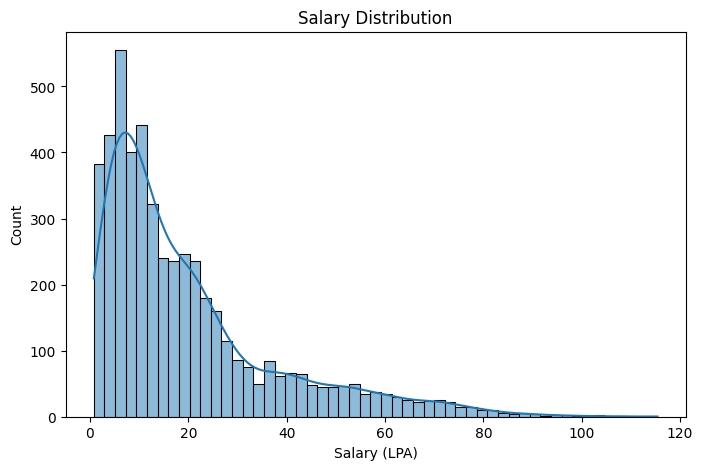

In [515]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary_LPA"], kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary (LPA)")
plt.ylabel("Count")
plt.show()

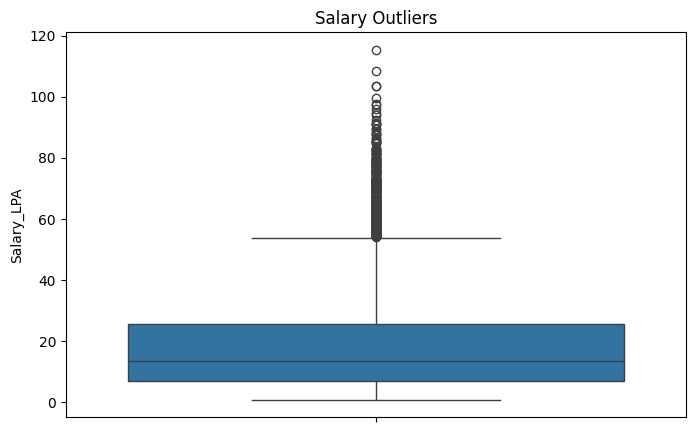

In [516]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Salary_LPA"])

plt.title("Salary Outliers")
plt.show()

In [517]:
print(df["Salary_LPA"].describe())

count    5000.000000
mean       19.829440
std        18.136741
min         0.800000
25%         6.800000
50%        13.600000
75%        25.600000
max       115.400000
Name: Salary_LPA, dtype: float64


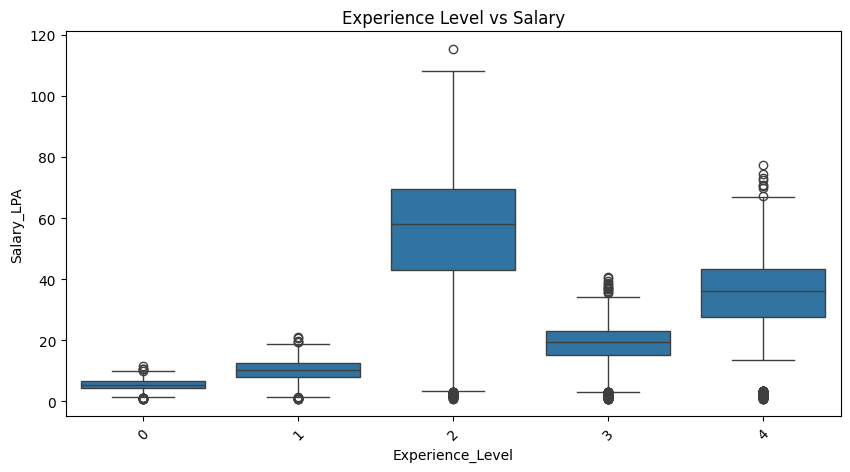

In [518]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="Experience_Level",
    y="Salary_LPA",
    data=df
)

plt.title("Experience Level vs Salary")
plt.xticks(rotation=45)
plt.show()

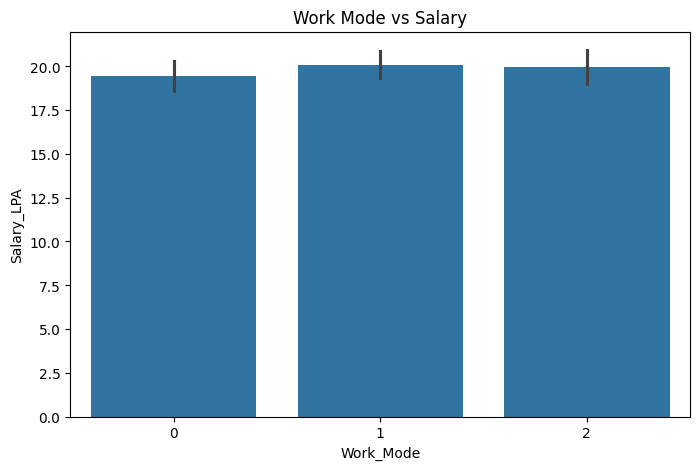

In [519]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Work_Mode",
    y="Salary_LPA",
    data=df
)

plt.title("Work Mode vs Salary")
plt.show()

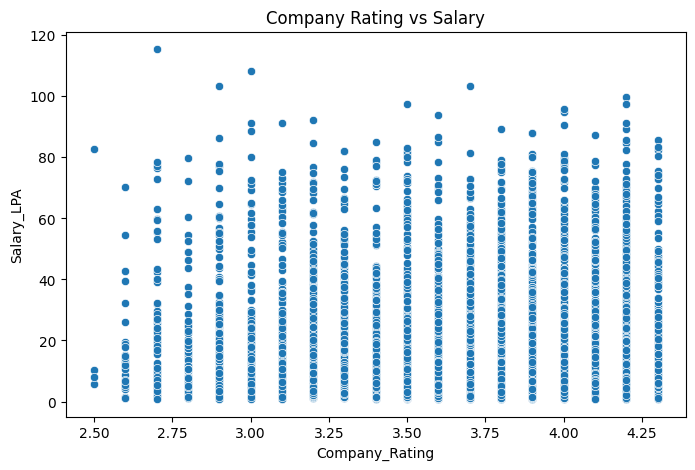

In [520]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Company_Rating",
    y="Salary_LPA",
    data=df
)

plt.title("Company Rating vs Salary")
plt.show()

In [521]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# model_le = LinearRegression()



In [522]:
# model.fit(X_train_sc, y_train)
# y_pred = model.predict(X_test_sc)

In [523]:
# y_pred_le

In [524]:
# score = r2_score(y_test, y_pred_le)
# score


In [525]:
from sklearn.tree import DecisionTreeRegressor
model_dt = DecisionTreeRegressor()


model_dt.fit(X_train,y_train)

DecisionTreeRegressor()

In [526]:
y_pred_dt = model_dt.predict(X_test)

In [527]:
y_pred_dt

array([  8.8,  35.7,  75.4,  27.8,   1.4,   9.4,  12.3,  80. ,  12.6,
        22.2,  19.8,  20.8,  24.4,   5.7,  21.7,  73. ,  26.1,   6. ,
        11.4,  27.7,   5.2,  24.9,   6.3,  27.6,   1. ,  23.1,   5.8,
         7.1,  11.4,   1. ,   1.5,  10.8,  20.8,  25.7,  10.2,  10.8,
        33.8,   7.6,  19.3,   9.5,   2.1,  14.6,  59.8,  19.6,  23.1,
        12.7,  10.9,  33.9,  21.5,  20.7,  14.9,   6.5,  62.7,  31.4,
         4.8,  20.4,   9.4,  57.2,  27. ,  84.7,   7. ,  42.8,   6.6,
         9.8,  12.8,   4.9,   9.8,  31.2,   5.1,  33.9,   4.9,   4.8,
        37.1,  16.7,  15. ,   1.1,  37.4,   4.9,  62.1,  17.9,   4.9,
        18.3,   4. ,  27.1,  80. ,   8.1,  16. ,  15. ,  21.6,   2.2,
        27.4,   8.8,  16.7,   8.1,   3.8,   4.6,  24. ,  85.5,  15.5,
        20. ,   1.8,  18.6,  13.4,  32. ,   5.3,  10.8,   9.5,   6.6,
         1.7,  27.4,  18.7,   0.8,  19. ,  12.7,   9.4,  11.3,  13.5,
        15.2,  27.6,  48. ,  23.2,  15.3,  60. ,  43.5,  23. ,  36.9,
        62.7,  50.3,

In [528]:
score_dt = r2_score(y_test, y_pred_dt)
score_dt

0.8725490013504831

In [529]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor()
model_rf.fit(X_train,y_train)

RandomForestRegressor()

In [530]:
y_pred_rf = model_rf.predict(X_test)
y_pred_rf

array([ 7.53 , 32.523, 68.484, 32.328,  2.172, 10.367, 11.582, 79.9  ,
       14.305, 34.673, 20.336, 19.764, 18.915,  5.776, 19.867, 71.19 ,
       24.144,  6.09 , 12.269, 27.677,  5.236, 33.64 ,  7.234, 21.314,
        1.869, 26.249,  4.425,  7.37 ,  9.961,  2.299,  1.901, 10.444,
       19.324, 22.052, 11.011, 12.813, 42.433,  5.883, 23.662, 10.612,
        1.988, 13.956, 60.904, 19.795, 18.517, 10.781,  9.605, 27.082,
       18.881, 21.965, 20.501,  6.494, 42.044, 40.217,  5.459, 18.202,
       12.535, 38.98 , 25.432, 76.38 ,  5.58 , 48.753,  6.281, 11.807,
       11.026,  6.103, 11.439, 30.73 ,  7.31 , 45.447,  5.295,  5.52 ,
       49.917, 13.214, 20.76 ,  1.911, 28.96 ,  4.12 , 70.196, 19.802,
        5.42 , 18.611,  4.404, 18.14 , 72.126,  7.58 , 12.326, 20.393,
       19.576,  2.426, 24.251,  7.735, 14.346,  9.223,  5.16 ,  5.547,
       26.513, 74.439, 12.721, 19.713,  2.152, 20.457, 12.43 , 23.613,
        5.131, 10.567, 10.191,  5.686,  2.421, 35.293, 20.367,  1.772,
      

In [531]:
score_rf = r2_score(y_test, y_pred_rf)
score_rf


0.9355124504129073

In [532]:
from sklearn.ensemble import GradientBoostingRegressor
model_gbr = GradientBoostingRegressor()
model_gbr.fit(X_train,y_train)

GradientBoostingRegressor()

In [533]:
y_pred_gbr = model_gbr.predict(X_test)
y_pred_gbr

array([ 8.04012775, 34.01977482, 62.0934429 , 32.9277069 ,  7.10258797,
       10.62624374,  8.91724146, 70.25817631, 10.99178451, 32.64356249,
       18.86466466, 21.48103151, 23.61529399,  6.95217698, 22.29841529,
       57.32426484, 38.38655251,  7.10923585, 12.17372894, 28.57801398,
        5.36123966, 32.44196045,  8.16424107, 22.39075792, -7.01403731,
       25.28820211,  0.93791208,  7.94055442, 10.23127371,  7.55716162,
        0.83964931,  9.82799939, 21.76123323, 22.35859237, 11.58445556,
       11.89897491, 38.72520094,  6.99074498, 25.18546043, 10.44796777,
        1.40277858, 13.90312056, 52.76599948, 19.83783432, 21.33832741,
       11.737016  , 10.81782375, 33.99088883, 22.2744091 , 22.41236006,
       19.70952661,  7.03278183, 31.58785389, 38.17654269,  5.58640622,
       19.02827724, 12.09751165, 37.92431819, 25.68642196, 69.53552958,
        7.15625082, 45.94406379,  7.16643773, 12.30856801, 11.20029605,
        6.92081371,  9.01316114, 32.13181334,  8.08832524, 45.51

In [534]:
score_gbr = r2_score(y_test, y_pred_gbr)
score_gbr

0.9049118035942272

In [535]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor()
model_xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [536]:
y_pred_xgb = model_xgb.predict(X_test)
y_pred_xgb

array([ 8.12914276e+00,  3.79866638e+01,  7.18395081e+01,  3.23317604e+01,
        7.95486450e+00,  1.27325535e+01,  1.03523712e+01,  8.40237885e+01,
        1.54032545e+01,  3.39163742e+01,  1.63207970e+01,  2.25392246e+01,
        1.75588608e+01,  6.03601503e+00,  2.19797001e+01,  7.00416718e+01,
        3.03484306e+01,  7.81399345e+00,  1.38241196e+01,  2.29908180e+01,
        6.25007582e+00,  3.29808273e+01,  1.03818989e+01,  1.86138954e+01,
       -4.08163929e+00,  2.78876381e+01,  4.44301605e+00,  7.82792044e+00,
        9.33205795e+00,  3.47929740e+00,  2.72443891e+00,  8.26887608e+00,
        2.14024048e+01,  2.17081089e+01,  1.04163322e+01,  1.23137903e+01,
        4.47131920e+01,  6.31102180e+00,  2.60718765e+01,  1.18739967e+01,
        2.59449935e+00,  1.61746254e+01,  5.73958168e+01,  1.96767540e+01,
        2.29893894e+01,  1.59041576e+01,  9.65762329e+00,  2.71213989e+01,
        1.53949051e+01,  1.94107246e+01,  2.09917259e+01,  4.42034531e+00,
        4.57144241e+01,  

In [537]:
score_xgb = r2_score(y_test, y_pred_xgb)
score_xgb

0.936445178824606

In [538]:
results = {
    "Model": [
        "Random Forest",
        "XGBoost",
        "Gradient Boosting",
        "Decision Tree"
    ],
    "R2 Score": [
        0.9336881005833841,
        0.9302234074056324,
        0.9051053154644636,
        0.8580912855799928
    ]
}

result_df = pd.DataFrame(results)

result_df = result_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(result_df)

               Model  R2 Score
0      Random Forest  0.933688
1            XGBoost  0.930223
2  Gradient Boosting  0.905105
3      Decision Tree  0.858091


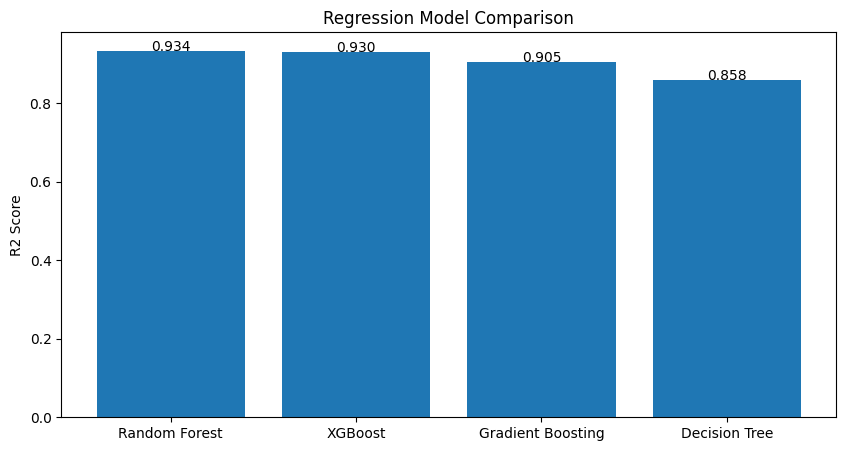

In [539]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    result_df["Model"],
    result_df["R2 Score"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center"
    )

plt.title("Regression Model Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)

plt.show()

In [540]:
import joblib

best_model = RandomForestRegressor()

best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [541]:
import joblib

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor
)
from xgboost import XGBRegressor

models = {
    "decision_tree": DecisionTreeRegressor(random_state=42),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
    "xgboost": XGBRegressor(random_state=42)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    joblib.dump(model, f"{name}.pkl")

    print(f"{name}.pkl saved successfully")

decision_tree.pkl saved successfully
gradient_boosting.pkl saved successfully
xgboost.pkl saved successfully


In [542]:
import joblib

joblib.dump(model_rf, "random_forest.pkl", compress=3)


['random_forest.pkl']

In [543]:
joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']